## Referencing Lab 8 SNOTEL Plotting

In [2]:
import os
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import folium
import contextily as ctx
import scipy.stats
import scipy.interpolate
import tqdm
from pathlib import Path
import xarray as xr
import skgstat as skg
import seaborn as sns
import pysal
from pysal.explore import esda
from pysal.lib import weights
from splot.esda import moran_scatterplot
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from matplotlib_scalebar.scalebar import ScaleBar

/opt/conda/lib/python3.11/site-packages/spaghetti/network.py:41: FutureWarning: The next major release of pysal/spaghetti (2.0.0) will drop support for all ``libpysal.cg`` geometries. This change is a first step in refactoring ``spaghetti`` that is expected to result in dramatically reduced runtimes for network instantiation and operations. Users currently requiring network and point pattern input as ``libpysal.cg`` geometries should prepare for this simply by converting to ``shapely`` geometries.
  warnings.warn(dep_msg, FutureWarning, stacklevel=1)


In [3]:
snotel_data_dir = f'{Path.home()}/gda_demo_data/snotel_data'

In [4]:
!ls -lh {snotel_data_dir}

total 1.1G
-rw-rw-r-- 1 jovyan users 1.1G Feb 27 21:48 snotel_data.nc
-rw-rw-r-- 1 jovyan users 456K Feb 27 21:47 snotel_stations.geojson


In [5]:
all_stations_gdf = gpd.read_file(f'{snotel_data_dir}/snotel_stations.geojson').set_index('code')
all_stations_gdf

,name,network,elevation_m,latitude,longitude,state,HUC,mgrs,mountainRange,beginDate,endDate,csvData,geometry
code,,,,,,,,,,,,,
301_CA_SNTL,Adin Mtn,SNOTEL,1886.712036,41.235828,-120.791924,California,180200021403,10TFL,Great Basin Ranges,1983-10-01,2026-02-26,True,POINT (-120.79192 41.23583)
907_UT_SNTL,Agua Canyon,SNOTEL,2712.719971,37.522171,-112.271179,Utah,160300020301,12SUG,Colorado Plateau,1994-10-01,2026-02-26,True,POINT (-112.27118 37.52217)
916_MT_SNTL,Albro Lake,SNOTEL,2529.840088,45.597229,-111.959023,Montana,100200050701,12TVR,Central Montana Rocky Mountains,1996-09-01,2026-02-26,True,POINT (-111.95902 45.59723)
1267_AK_SNTL,Alexander Lake,SNOTEL,48.768002,61.749668,-150.889664,Alaska,190205051106,05VPJ,None,2014-08-28,2026-02-26,True,POINT (-150.88966 61.74967)
908_WA_SNTL,Alpine Meadows,SNOTEL,1066.800049,47.779572,-121.698471,Washington,171100100501,10TET,Cascade Range,1994-09-01,2026-02-26,True,POINT (-121.69847 47.77957)
...,...,...,...,...,...,...,...,...,...,...,...,...,...
SLT,Slate Creek,CCSS,1737.360000,41.043980,-122.480103,California,180200050304,10TEL,Klamath Mountains,2004-10-01,2026-02-26,True,POINT (-122.4801 41.04398)
SLI,Slide Canyon,CCSS,2804.160000,38.091234,-119.431881,California,180400090501,11SKC,Sierra Nevada,2005-10-01,2026-02-26,True,POINT (-119.43188 38.09123)
SLK,South Lake,CCSS,2926.080000,37.175903,-118.562660,California,180901020601,11SLB,Sierra Nevada,2004-10-01,2026-02-26,True,POINT (-118.56266 37.1759)


### Exploring to find ID of desired SNOTEL Station

In [6]:
#all_stations_gdf.drop(columns=['beginDate','endDate']).explore(column='elevation_m', cmap='inferno')

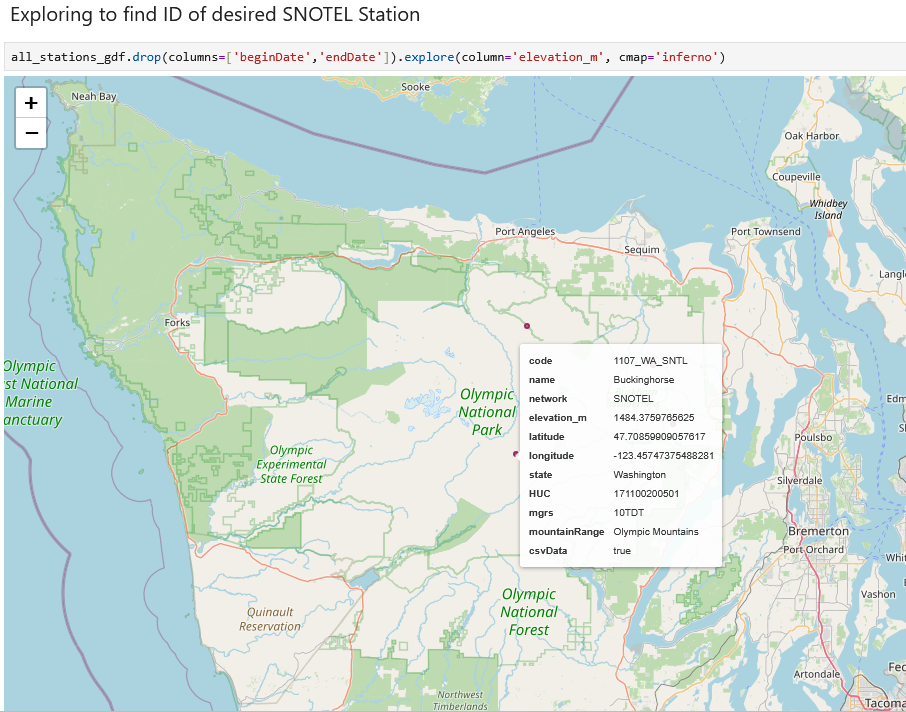

#### Second highest in the park, less than 1000m under the highest which is waterhole

In [7]:
#all_stations_gdf.crs # in 4326, need 32610
all_stations_gdf = all_stations_gdf.to_crs('EPSG:32610')
all_stations_gdf.crs # GOOD

<Projected CRS: EPSG:32610>
Name: WGS 84 / UTM zone 10N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 126°W and 120°W, northern hemisphere between equator and 84°N, onshore and offshore. Canada - British Columbia (BC); Northwest Territories (NWT); Nunavut; Yukon. United States (USA) - Alaska (AK).
- bounds: (-126.0, 0.0, -120.0, 84.0)
Coordinate Operation:
- name: UTM zone 10N
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [8]:
snotel_ds = xr.open_dataset(f'{snotel_data_dir}/snotel_data.nc').load()
snotel_ds

<xarray.Dataset> Size: 1GB
Dimensions:        (station: 969, time: 24537)
Coordinates: (12/16)
  * time           (time) datetime64[ns] 196kB 1909-04-13 ... 2026-02-26
  * station        (station) <U12 47kB '1141_CO_SNTL' 'CAP' ... '572_UT_SNTL'
    name           (station) <U24 93kB 'Upper Taylor' ... 'Lasal Mountain'
    network        (station) <U6 23kB 'SNOTEL' 'CCSS' ... 'SNOTEL' 'SNOTEL'
    elevation_m    (station) float64 8kB 3.243e+03 2.438e+03 ... 2.919e+03
    latitude       (station) float64 8kB 38.99 38.71 41.35 ... 42.76 42.05 38.48
    ...             ...
    mountainRange  (station) <U32 124kB 'Southern Rocky Mountains' ... 'Color...
    beginDate      (station) datetime64[ns] 8kB 2009-08-26T15:00:00 ... 1980-...
    endDate        (station) datetime64[ns] 8kB 2026-02-26 ... 2026-02-26
    csvData        (station) bool 969B True True True True ... True True True
    WY             (time) int64 196kB 1909 1955 1955 1955 ... 2026 2026 2026
    DOWY           (time) int64 196kB 195 62 63 64 65 66 ... 145 146 147 148 149
Data variables:
    TAVG           (station, time) float64 190MB nan nan nan ... -99.9 3.2 nan
    TMIN           (station, time) float64 190MB nan nan nan ... nan -0.8 nan
    TMAX           (station, time) float64 190MB nan nan nan nan ... nan 6.5 nan
    SNWD           (station, time) float64 190MB nan nan nan ... 0.5334 0.508
    WTEQ           (station, time) float64 190MB nan nan nan ... 0.1676 0.1626
    PRCPSA         (station, time) float64 190MB nan nan nan ... 0.0025 0.0 nan

# Buckinghorse SNOTEL Data

In [9]:
station_id = '1107_WA_SNTL'  #CODE for Buckinghorse

In [10]:
buckinghorse_snotel_ds = snotel_ds.sel(station=station_id)

In [11]:
buckinghorse_snotel_df = buckinghorse_snotel_ds.to_pandas()[['SNWD', 'TAVG','PRCPSA','WY','DOWY']]
buckinghorse_snotel_df

,SNWD,TAVG,PRCPSA,WY,DOWY
time,,,,,
1909-04-13,NaN,NaN,NaN,1909,195
1954-12-01,NaN,NaN,NaN,1955,62
1954-12-02,NaN,NaN,NaN,1955,63
1954-12-03,NaN,NaN,NaN,1955,64
1954-12-04,NaN,NaN,NaN,1955,65
...,...,...,...,...,...
2026-02-22,1.5240,-0.3,0.0610,2026,145
2026-02-23,1.8796,-1.7,0.0254,2026,146
2026-02-24,1.8034,-2.0,0.0000,2026,147


Text(0.5, 1.0, 'Snow Depth vs. Day of Water Year at Buckinghorse')

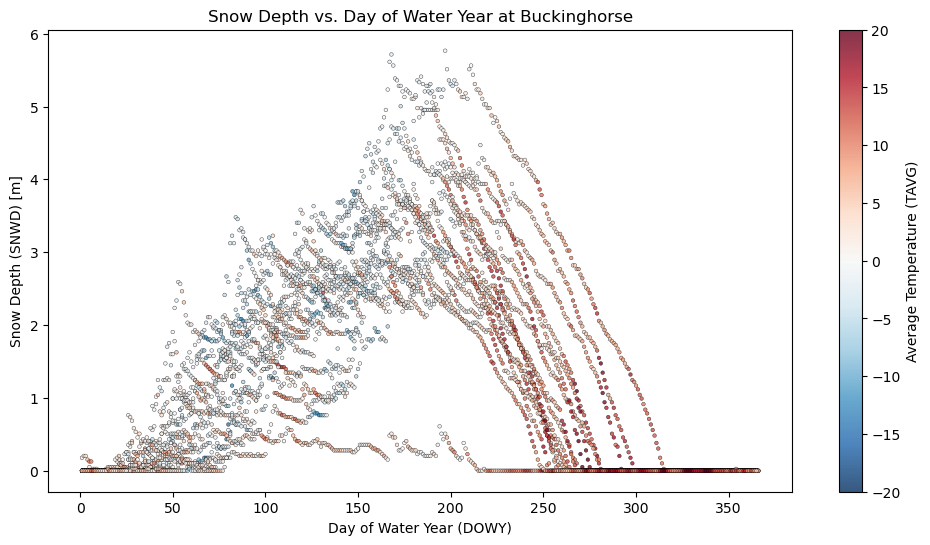

In [12]:
f,ax= plt.subplots(figsize=(12,6))
buckinghorse_sd = plt.scatter(buckinghorse_snotel_df.DOWY, buckinghorse_snotel_df.SNWD, c =buckinghorse_snotel_df.TAVG, cmap='RdBu_r', vmin=-20, vmax=20, s= 7, edgecolor = 'k', linewidth=0.3, alpha=0.8)
f.colorbar(buckinghorse_sd, ax=ax, label="Average Temperature (TAVG)")
ax.set_xlabel('Day of Water Year (DOWY)')
ax.set_ylabel('Snow Depth (SNWD) [m]')
ax.set_title('Snow Depth vs. Day of Water Year at Buckinghorse')

In [13]:
stat_list = ['count','min','max','mean','std','median']

In [14]:
dowy_stats = buckinghorse_snotel_df.groupby('DOWY').agg(stat_list)
dowy_stats 

SNWD                                          TAVG             \
     count  min     max      mean       std median count  min   max   
DOWY                                                                  
1       18  0.0  0.1778  0.009878  0.041908    0.0    18  1.4  17.4   
2       18  0.0  0.2032  0.011289  0.047895    0.0    18  1.5  16.5   
3       18  0.0  0.2032  0.011289  0.047895    0.0    18  0.7  16.3   
4       18  0.0  0.1524  0.008467  0.035921    0.0    18  2.0  14.9   
5       18  0.0  0.1270  0.009878  0.031579    0.0    18  1.9  13.9   
...    ...  ...     ...       ...       ...    ...   ...  ...   ...   
362     18  0.0  0.0000  0.000000  0.000000    0.0    17  2.6  15.9   
363     18  0.0  0.0000  0.000000  0.000000    0.0    17  0.6  14.8   
364     18  0.0  0.0000  0.000000  0.000000    0.0    17 -0.3  15.2   
365     18  0.0  0.0000  0.000000  0.000000    0.0    17  1.0  19.7   
366      5  0.0  0.0000  0.000000  0.000000    0.0     4  5.6  18.3   

                 ...  PRCPSA                                WY              \
           mean  ...     max      mean       std  median count   min   max   
DOWY             ...                                                         
1      8.188889  ...  0.0356  0.006917  0.012234  0.0000    70  1956  2026   
2      6.944444  ...  0.0254  0.004650  0.008319  0.0000    70  1956  2026   
3      6.727778  ...  0.0508  0.006350  0.014684  0.0000    70  1956  2026   
4      7.044444  ...  0.0559  0.009172  0.016789  0.0000    70  1956  2026   
5      7.816667  ...  0.0229  0.003817  0.006719  0.0000    70  1956  2026   
...         ...  ...     ...       ...       ...     ...   ...   ...   ...   
362    8.941176  ...  0.0432  0.006663  0.011619  0.0000    62  1964  2025   
363    8.282353  ...  0.1473  0.010900  0.035326  0.0000    62  1964  2025   
364    7.982353  ...  0.0965  0.010306  0.024909  0.0000    62  1964  2025   
365    7.352941  ...  0.0508  0.009706  0.017620  0.0000    62  1964  2025   
366   10.575000  ...  0.0051  0.002533  0.002550  0.0025    16  1964  2024   

                                      
             mean        std  median  
DOWY                                  
1     1991.414286  20.489299  1991.5  
2     1991.414286  20.489299  1991.5  
3     1991.414286  20.489299  1991.5  
4     1991.414286  20.489299  1991.5  
5     1991.414286  20.489299  1991.5  
...           ...        ...     ...  
362   1994.500000  18.041619  1994.5  
363   1994.500000  18.041619  1994.5  
364   1994.500000  18.041619  1994.5  
365   1994.500000  18.041619  1994.5  
366   1994.000000  19.043809  1994.0  

[366 rows x 24 columns]

In [15]:
max_snwd_wday =dowy_stats['SNWD', 'max'].idxmax()
max_snwd = dowy_stats['SNWD', 'max'].max()
 
caldate = pd.to_datetime('2021-09-30')+pd.to_timedelta(max_snwd_wday, unit='D')
calmonthday = caldate.strftime('%B %d')
print(f'The highest average snow depth occured on day of water year: {max_snwd_wday}, which corresponds to {calmonthday}, with an average snow depth of {max_snwd}m')

The highest average snow depth occured on day of water year: 197, which corresponds to April 15, with an average snow depth of 5.7658m


In [16]:
std_upper = dowy_stats['SNWD', 'mean'] + dowy_stats['SNWD', 'std']
std_lower = dowy_stats['SNWD', 'mean'] - dowy_stats['SNWD', 'std']
current_year_snwd = buckinghorse_snotel_df['SNWD'].where(buckinghorse_snotel_df['WY']==2026)
current_year_dowy = buckinghorse_snotel_df['DOWY'].where(buckinghorse_snotel_df['WY']==2026)

(0.0, 6.072481185094771)

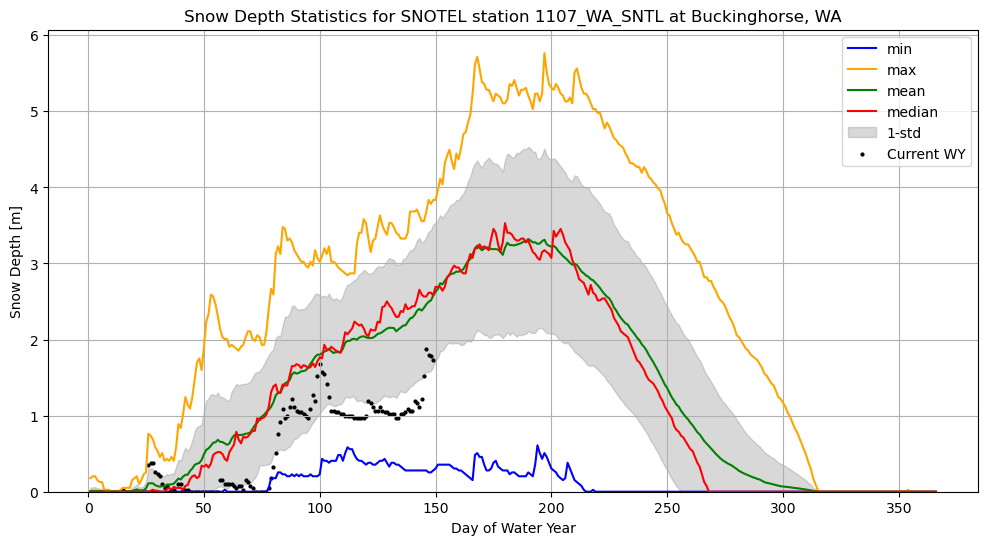

In [17]:
f,ax = plt.subplots(figsize=(12,6))
dowy_stats['SNWD', 'min'].plot(ax=ax, x='DOWY', color='blue', label='min')
dowy_stats['SNWD', 'max'].plot(ax=ax, x='DOWY', color='orange', label='max')
dowy_stats['SNWD', 'mean'].plot(ax=ax, x='DOWY', color='green', label='mean')
dowy_stats['SNWD', 'median'].plot(ax=ax, x='DOWY', color='red', label='median')
ax.fill_between(dowy_stats.index, std_upper, std_lower, color='grey', alpha=0.3, label='1-std')
plt.scatter(current_year_dowy, current_year_snwd, color='k', label = 'Current WY', s=4)


ax.legend()
ax.grid()
ax.set_title('Snow Depth Statistics for SNOTEL station 1107_WA_SNTL at Buckinghorse, WA')
ax.set_xlabel('Day of Water Year')
ax.set_ylabel('Snow Depth [m]')
ax.set_ylim(0)

In [18]:
current_day_data = buckinghorse_snotel_df.iloc[-1]
current_day_month_date= current_day_data.name.strftime('%B %d, %Y')
current_dowy = int(current_day_data.DOWY)
print(f'Current snow depth as of {current_day_month_date} / DOWY {current_dowy}: {current_day_data.SNWD}m')

long_term_median = dowy_stats.loc[current_dowy, ('SNWD', 'median')]
print(f'Long-term median on DOWY {current_dowy}: {long_term_median}m')

current_percent_normal_snwd = current_day_data.SNWD/long_term_median *100
print(f'Percent of normal snow depth on DOWY {current_dowy}: {current_percent_normal_snwd:.2f}%')

Current snow depth as of February 26, 2026 / DOWY 149: 1.7272m
Long-term median on DOWY 149: 2.5781m
Percent of normal snow depth on DOWY 149: 67.00%


In [19]:
dowy_2023 = buckinghorse_snotel_df['DOWY'].where(buckinghorse_snotel_df['WY']==2023)
snwd_2023 = buckinghorse_snotel_df['SNWD'].where(buckinghorse_snotel_df['WY']==2023)
temp_2023 = buckinghorse_snotel_df['TAVG'].where(buckinghorse_snotel_df['WY']==2023)
precip_2023 = buckinghorse_snotel_df['PRCPSA'].where(buckinghorse_snotel_df['WY']==2023)

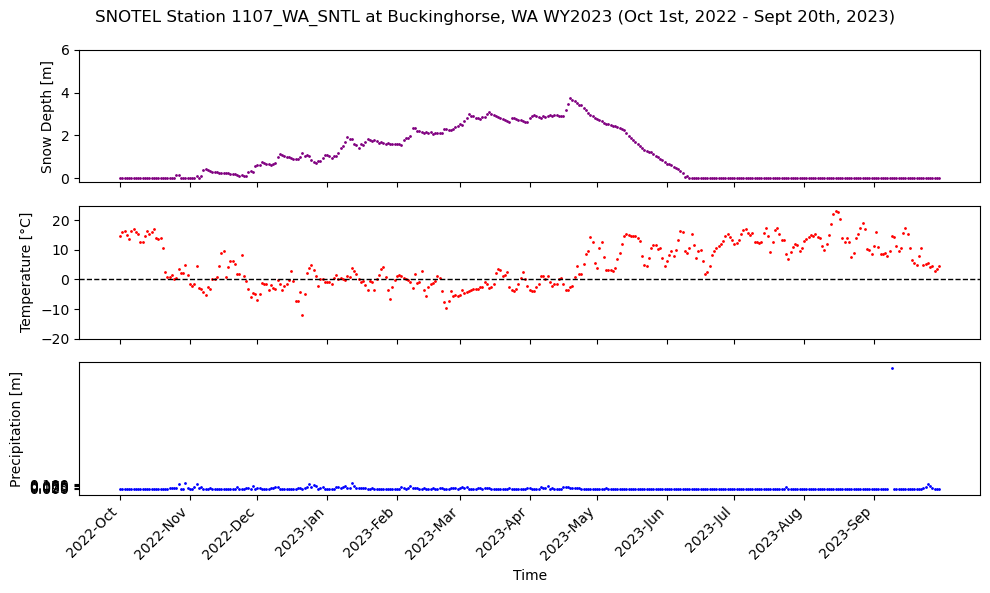

In [20]:
f, ax = plt.subplots(3,1,figsize = (10,6), sharex=True)

ax[0].scatter(snwd_2023.index, snwd_2023, color='purple', s=1)
ax[0].set_ylabel('Snow Depth [m]')
ax[0].set_yticks([0, 2, 4, 6])

ax[1].scatter(snwd_2023.index, temp_2023, color='red', s=1)
ax[1].axhline(0, ls='dashed', c='k', linewidth=1)
ax[1].set_ylabel('Temperature [°C]')
ax[1].set_yticks([-20, -10, 0, 10, 20])

ax[2].scatter(snwd_2023.index, precip_2023, color='blue', s=1)
ax[2].set_ylabel('Precipitation [m]')
ax[2].set_xlabel('Time')
ax[2].set_yticks([0.00, 0.025, 0.05, 0.075, 0.10])
ax[2].set_xticks(pd.date_range('2022-10-01', '2023-09-01', freq='MS'))
water_year_dates = pd.date_range('2022-10-01', '2023-09-01', freq='MS')
# This next line specifically took some time to troubleshoot, so I referenced CHATGPT for looping the conversion for each date provided
water_year_months = [d.strftime('%Y-%b') for d in water_year_dates]
ax[2].set_xticklabels(water_year_months, rotation=45,ha='right')   #https://matplotlib.org/2.0.0/api/_as_gen/matplotlib.axes.Axes.set_xticklabels.html


f.suptitle('SNOTEL Station 1107_WA_SNTL at Buckinghorse, WA WY2023 (Oct 1st, 2022 - Sept 20th, 2023)')
f.tight_layout()

# Waterhole SNOTEL DATA

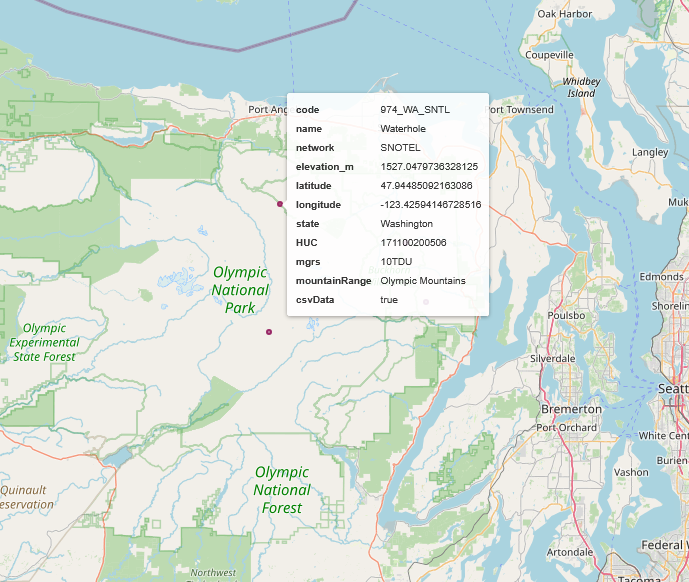

In [21]:
wh_station_id = '974_WA_SNTL'  #CODE for Waterhole

In [22]:
wh_snotel_ds = snotel_ds.sel(station=wh_station_id)

In [23]:
wh_snotel_df = wh_snotel_ds.to_pandas()[['SNWD', 'TAVG','PRCPSA','WY','DOWY']]
wh_snotel_df

,SNWD,TAVG,PRCPSA,WY,DOWY
time,,,,,
1909-04-13,NaN,NaN,NaN,1909,195
1954-12-01,NaN,NaN,NaN,1955,62
1954-12-02,NaN,NaN,NaN,1955,63
1954-12-03,NaN,NaN,NaN,1955,64
1954-12-04,NaN,NaN,NaN,1955,65
...,...,...,...,...,...
2026-02-22,0.8382,-0.9,0.0432,2026,145
2026-02-23,1.1176,-2.9,0.0254,2026,146
2026-02-24,1.1430,-3.8,0.0000,2026,147


/tmp/ipykernel_103/4255918956.py:3: UserWarning: Adding colorbar to a different Figure <Figure size 1200x600 with 2 Axes> than <Figure size 1200x600 with 2 Axes> which fig.colorbar is called on.
  f.colorbar(buckinghorse_sd, ax=ax, label="Average Temperature (TAVG)")


Text(0.5, 1.0, 'Snow Depth vs. Day of Water Year at Waterhole')

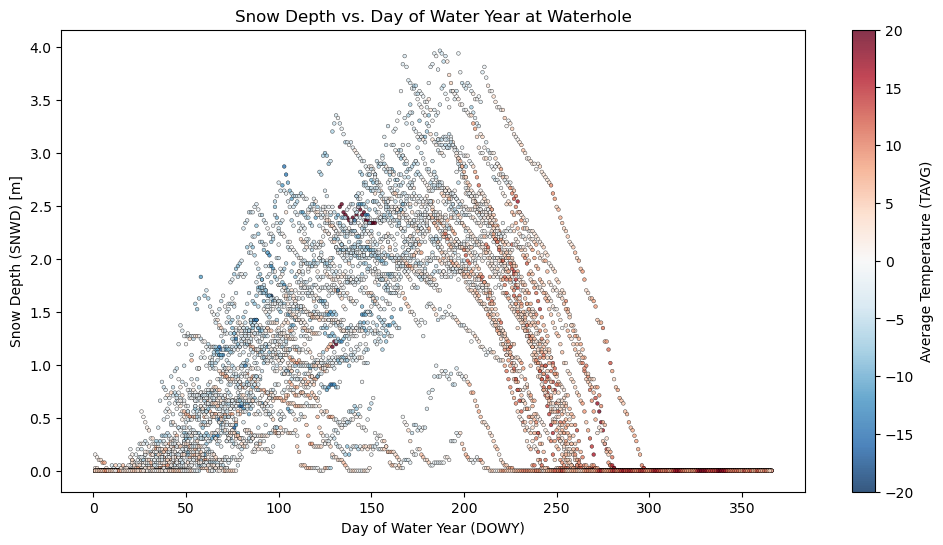

In [24]:
f,ax= plt.subplots(figsize=(12,6))
wh_sd = plt.scatter(wh_snotel_df.DOWY, wh_snotel_df.SNWD, c =wh_snotel_df.TAVG, cmap='RdBu_r', vmin=-20, vmax=20, s= 7, edgecolor = 'k', linewidth=0.3, alpha=0.8)
f.colorbar(buckinghorse_sd, ax=ax, label="Average Temperature (TAVG)")
ax.set_xlabel('Day of Water Year (DOWY)')
ax.set_ylabel('Snow Depth (SNWD) [m]')
ax.set_title('Snow Depth vs. Day of Water Year at Waterhole')

In [25]:
wh_stat_list = ['count','min','max','mean','std','median']

In [26]:
wh_dowy_stats = wh_snotel_df.groupby('DOWY').agg(stat_list)
wh_dowy_stats 

SNWD                                          TAVG                       \
     count  min     max      mean       std median count  min   max      mean   
DOWY                                                                            
1       26  0.0  0.1524  0.006838  0.030103    0.0    25  0.5  15.1  6.116000   
2       27  0.0  0.1270  0.005644  0.024740    0.0    25  0.1  13.8  5.356000   
3       27  0.0  0.1016  0.003763  0.019553    0.0    25 -1.2  13.8  5.252000   
4       27  0.0  0.1016  0.003763  0.019553    0.0    25 -1.8  13.8  5.744000   
5       27  0.0  0.0762  0.002822  0.014665    0.0    25 -0.6  11.5  5.864000   
...    ...  ...     ...       ...       ...    ...   ...  ...   ...       ...   
362     26  0.0  0.0000  0.000000  0.000000    0.0    24  1.7  15.5  7.750000   
363     26  0.0  0.0000  0.000000  0.000000    0.0    24 -0.5  16.5  7.250000   
364     26  0.0  0.0000  0.000000  0.000000    0.0    22 -1.2  14.9  7.986364   
365     26  0.0  0.0000  0.000000  0.000000    0.0    23 -1.0  15.8  6.039130   
366      7  0.0  0.0000  0.000000  0.000000    0.0     7  3.6  15.7  8.714286   

      ...  PRCPSA                               WY                           \
      ...     max      mean       std median count   min   max         mean   
DOWY  ...                                                                     
1     ...  0.0152  0.002248  0.004065    0.0    70  1956  2026  1991.414286   
2     ...  0.0152  0.002248  0.003938    0.0    70  1956  2026  1991.414286   
3     ...  0.0152  0.001874  0.003827    0.0    70  1956  2026  1991.414286   
4     ...  0.0203  0.001685  0.004283    0.0    70  1956  2026  1991.414286   
5     ...  0.0076  0.000969  0.001904    0.0    70  1956  2026  1991.414286   
...   ...     ...       ...       ...    ...   ...   ...   ...          ...   
362   ...  0.0102  0.001365  0.003067    0.0    62  1964  2025  1994.500000   
363   ...  0.0584  0.003415  0.011667    0.0    62  1964  2025  1994.500000   
364   ...  0.0533  0.004481  0.012022    0.0    62  1964  2025  1994.500000   
365   ...  0.0356  0.003415  0.008712    0.0    62  1964  2025  1994.500000   
366   ...  0.0203  0.003257  0.007573    0.0    16  1964  2024  1994.000000   

                         
            std  median  
DOWY                     
1     20.489299  1991.5  
2     20.489299  1991.5  
3     20.489299  1991.5  
4     20.489299  1991.5  
5     20.489299  1991.5  
...         ...     ...  
362   18.041619  1994.5  
363   18.041619  1994.5  
364   18.041619  1994.5  
365   18.041619  1994.5  
366   19.043809  1994.0  

[366 rows x 24 columns]

In [27]:
wh_max_snwd_wday =wh_dowy_stats['SNWD', 'max'].idxmax()
wh_max_snwd = wh_dowy_stats['SNWD', 'max'].max()
 
caldate = pd.to_datetime('2021-09-30')+pd.to_timedelta(wh_max_snwd_wday, unit='D')
calmonthday = caldate.strftime('%B %d')
print(f'The highest average snow depth occured on day of water year: {wh_max_snwd_wday}, which corresponds to {calmonthday}, with an average snow depth of {wh_max_snwd}m')

The highest average snow depth occured on day of water year: 187, which corresponds to April 05, with an average snow depth of 3.9624m


In [28]:
wh_std_upper = wh_dowy_stats['SNWD', 'mean'] + wh_dowy_stats['SNWD', 'std']
wh_std_lower = wh_dowy_stats['SNWD', 'mean'] - wh_dowy_stats['SNWD', 'std']
wh_current_year_snwd = wh_snotel_df['SNWD'].where(wh_snotel_df['WY']==2026)
wh_current_year_dowy = wh_snotel_df['DOWY'].where(wh_snotel_df['WY']==2026)

(0.0, 4.173295696129199)

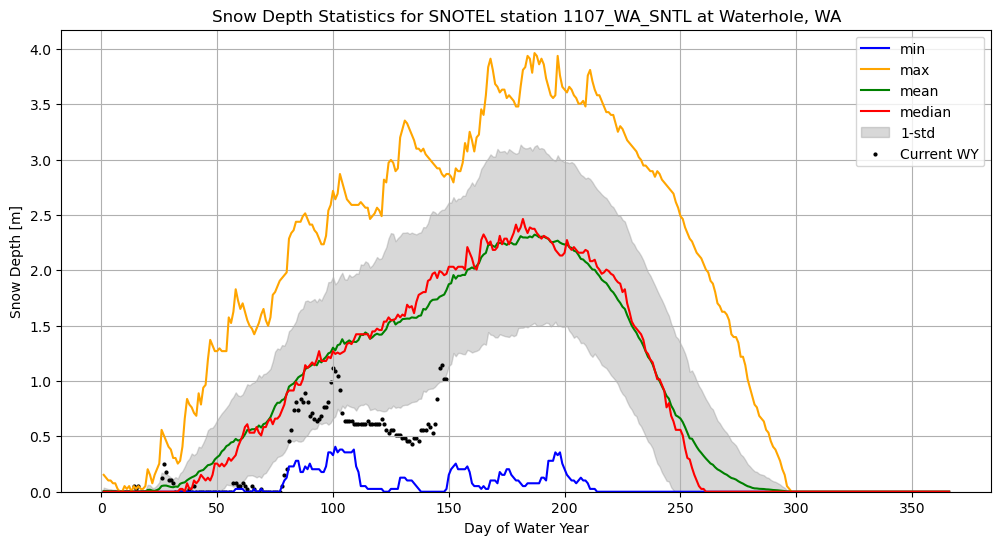

In [29]:
f,ax = plt.subplots(figsize=(12,6))
wh_dowy_stats['SNWD', 'min'].plot(ax=ax, x='DOWY', color='blue', label='min')
wh_dowy_stats['SNWD', 'max'].plot(ax=ax, x='DOWY', color='orange', label='max')
wh_dowy_stats['SNWD', 'mean'].plot(ax=ax, x='DOWY', color='green', label='mean')
wh_dowy_stats['SNWD', 'median'].plot(ax=ax, x='DOWY', color='red', label='median')
ax.fill_between(wh_dowy_stats.index, wh_std_upper, wh_std_lower, color='grey', alpha=0.3, label='1-std')
plt.scatter(wh_current_year_dowy, wh_current_year_snwd, color='k', label = 'Current WY', s=4)


ax.legend()
ax.grid()
ax.set_title('Snow Depth Statistics for SNOTEL station 1107_WA_SNTL at Waterhole, WA')
ax.set_xlabel('Day of Water Year')
ax.set_ylabel('Snow Depth [m]')
ax.set_ylim(0)

In [30]:
wh_current_day_data = wh_snotel_df.iloc[-1]
wh_current_day_month_date= wh_current_day_data.name.strftime('%B %d, %Y')
wh_current_dowy = int(wh_current_day_data.DOWY)
print(f'Current snow depth as of {wh_current_day_month_date} / DOWY {wh_current_dowy}: {wh_current_day_data.SNWD}m')

wh_long_term_median = dowy_stats.loc[wh_current_dowy, ('SNWD', 'median')]
print(f'Long-term median on DOWY {wh_current_dowy}: {wh_long_term_median}m')

wh_current_percent_normal_snwd = wh_current_day_data.SNWD/wh_long_term_median *100
print(f'Percent of normal snow depth on DOWY {wh_current_dowy}: {wh_current_percent_normal_snwd:.2f}%')

Current snow depth as of February 26, 2026 / DOWY 149: 1.016m
Long-term median on DOWY 149: 2.5781m
Percent of normal snow depth on DOWY 149: 39.41%


In [31]:
wh_dowy_2023 = wh_snotel_df['DOWY'].where(wh_snotel_df['WY']==2023)
wh_snwd_2023 = wh_snotel_df['SNWD'].where(wh_snotel_df['WY']==2023)
wh_temp_2023 = wh_snotel_df['TAVG'].where(wh_snotel_df['WY']==2023)
wh_precip_2023 = wh_snotel_df['PRCPSA'].where(wh_snotel_df['WY']==2023)

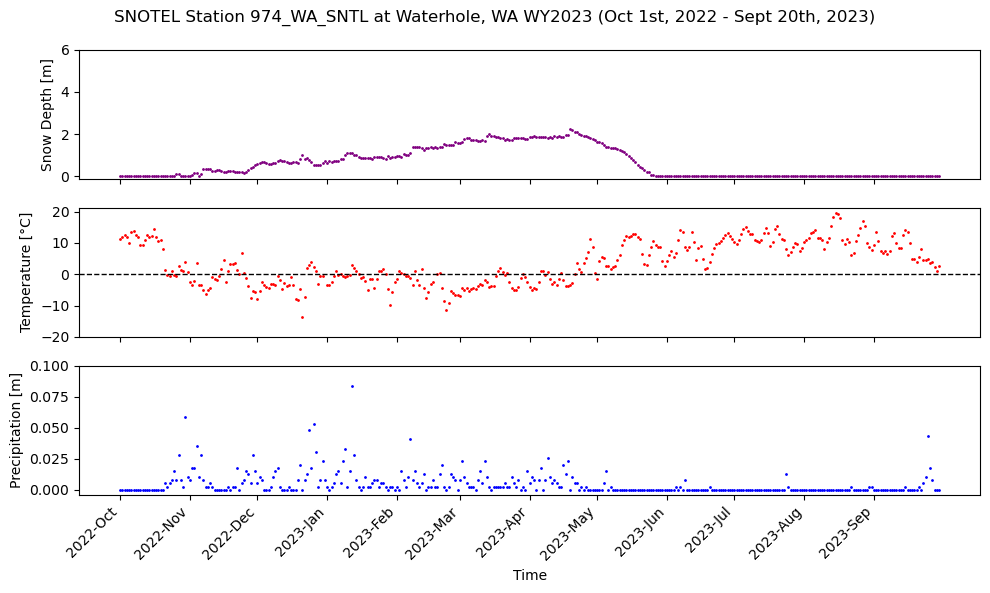

In [32]:
f, ax = plt.subplots(3,1,figsize = (10,6), sharex=True)

ax[0].scatter(wh_snwd_2023.index, wh_snwd_2023, color='purple', s=1)
ax[0].set_ylabel('Snow Depth [m]')
ax[0].set_yticks([0, 2, 4, 6])

ax[1].scatter(wh_snwd_2023.index, wh_temp_2023, color='red', s=1)
ax[1].axhline(0, ls='dashed', c='k', linewidth=1)
ax[1].set_ylabel('Temperature [°C]')
ax[1].set_yticks([-20, -10, 0, 10, 20])

ax[2].scatter(wh_snwd_2023.index, wh_precip_2023, color='blue', s=1)
ax[2].set_ylabel('Precipitation [m]')
ax[2].set_xlabel('Time')
ax[2].set_yticks([0.00, 0.025, 0.05, 0.075, 0.10])
ax[2].set_xticks(pd.date_range('2022-10-01', '2023-09-01', freq='MS'))
water_year_dates = pd.date_range('2022-10-01', '2023-09-01', freq='MS')
# This next line specifically took some time to troubleshoot, so I referenced CHATGPT for looping the conversion for each date provided
water_year_months = [d.strftime('%Y-%b') for d in water_year_dates]
ax[2].set_xticklabels(water_year_months, rotation=45,ha='right')   #https://matplotlib.org/2.0.0/api/_as_gen/matplotlib.axes.Axes.set_xticklabels.html


f.suptitle('SNOTEL Station 974_WA_SNTL at Waterhole, WA WY2023 (Oct 1st, 2022 - Sept 20th, 2023)')
f.tight_layout()